In [1]:
# read in the entertainment data
import pandas as pd
 
df = pd.read_csv('entertainment_clean.csv')
df.head()

,name,books,tv_shows,video_games
0,Aaliyah,0.5,4.6,4.9
1,Abigail,0.0,4.5,4.8
2,Addison,0.5,4.5,5.0
3,Adeline,3.5,4.5,6.6
4,Alana,2.8,3.8,5.6


In [2]:
# keep only the numeric columns
X = df.iloc[:, 1:]
X.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


In [3]:
# import isolation forest from sklearn
from sklearn.ensemble import IsolationForest

In [4]:
# fit an isolation forest model with 2% of the data set as anomalies
model = IsolationForest(contamination=0.02)
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [5]:
# view the anomaly scores
df['anomaly_scores'] = model.decision_function(X)
df.sort_values('anomaly_scores').head(10)

,name,books,tv_shows,video_games,anomaly_scores
110,Octavia,5.0,5.7,7.9,-0.041649
15,Avery,1.0,6.6,5.7,-0.022567
147,Zara,5.5,5.7,7.7,-0.019515
37,Elena,0.8,3.4,4.5,0.000398
29,Clementine,6.2,5.4,7.2,0.000411
19,Bianca,5.8,3.9,7.7,0.005101
58,Hailey,2.5,3.0,5.0,0.012853
148,Zoe,0.0,6.1,5.2,0.028471
129,Sofia,0.5,6.0,5.8,0.032955
42,Elizabeth,0.0,4.5,4.3,0.039087


In [6]:
# view the anomaly flags
df['anomaly'] = model.predict(X)
df.sort_values('anomaly_scores').head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly
110,Octavia,5.0,5.7,7.9,-0.041649,-1
15,Avery,1.0,6.6,5.7,-0.022567,-1
147,Zara,5.5,5.7,7.7,-0.019515,-1
37,Elena,0.8,3.4,4.5,0.000398,1
29,Clementine,6.2,5.4,7.2,0.000411,1
19,Bianca,5.8,3.9,7.7,0.005101,1
58,Hailey,2.5,3.0,5.0,0.012853,1
148,Zoe,0.0,6.1,5.2,0.028471,1
129,Sofia,0.5,6.0,5.8,0.032955,1
42,Elizabeth,0.0,4.5,4.3,0.039087,1


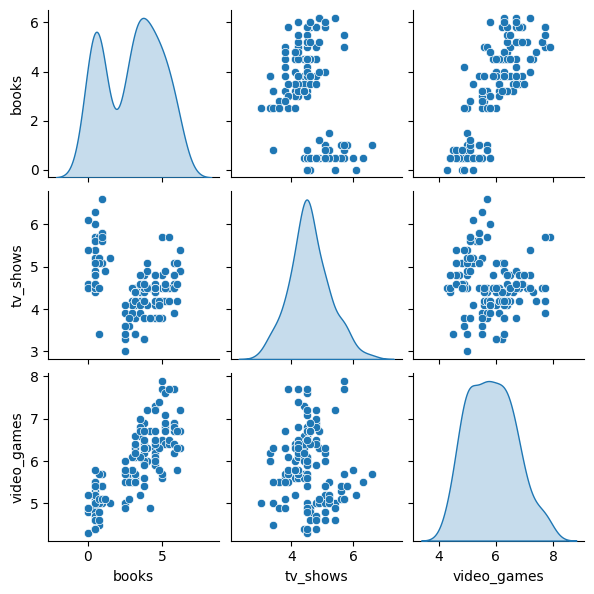

In [7]:
# view a pair plot of the original data set
import seaborn as sns
 
sns.pairplot(X, diag_kind='kde', height=2);

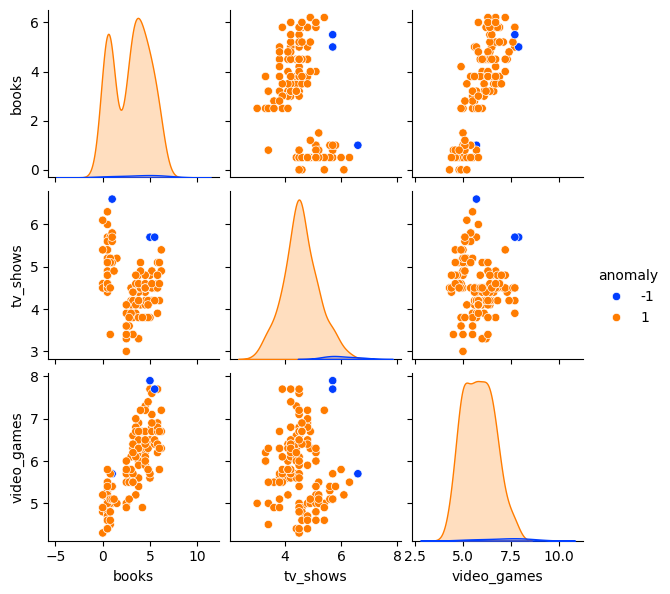

In [8]:
# overlay the isolation forest detected outliers
sns.pairplot(df.drop(columns='anomaly_scores'), hue='anomaly', palette='bright', height=2);

In [9]:
# update the model to flag 5% of rows as anomalies
model5 = IsolationForest(contamination=0.05, random_state=42)
model5.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [10]:
# view the anomaly scores
df['anomaly_scores_5'] = model5.decision_function(X)
df.sort_values('anomaly_scores_5').head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5
110,Octavia,5.0,5.7,7.9,-0.041649,-1,-0.040416
15,Avery,1.0,6.6,5.7,-0.022567,-1,-0.034753
37,Elena,0.8,3.4,4.5,0.000398,1,-0.034636
147,Zara,5.5,5.7,7.7,-0.019515,-1,-0.027916
148,Zoe,0.0,6.1,5.2,0.028471,1,-0.017880
29,Clementine,6.2,5.4,7.2,0.000411,1,-0.017022
58,Hailey,2.5,3.0,5.0,0.012853,1,-0.008977
42,Elizabeth,0.0,4.5,4.3,0.039087,1,-0.006022
109,Nora,0.5,6.3,5.5,0.052779,1,0.007360
19,Bianca,5.8,3.9,7.7,0.005101,1,0.008350


In [11]:
# view the anomaly flags
df['anomaly_5'] = model5.predict(X)
df.sort_values('anomaly_5').head(10)

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5,anomaly_5
15,Avery,1.0,6.6,5.7,-0.022567,-1,-0.034753,-1
29,Clementine,6.2,5.4,7.2,0.000411,1,-0.017022,-1
42,Elizabeth,0.0,4.5,4.3,0.039087,1,-0.006022,-1
37,Elena,0.8,3.4,4.5,0.000398,1,-0.034636,-1
58,Hailey,2.5,3.0,5.0,0.012853,1,-0.008977,-1
110,Octavia,5.0,5.7,7.9,-0.041649,-1,-0.040416,-1
147,Zara,5.5,5.7,7.7,-0.019515,-1,-0.027916,-1
148,Zoe,0.0,6.1,5.2,0.028471,1,-0.017880,-1
7,Amara,3.2,4.5,5.6,0.201949,1,0.175484,1
8,Amelia,0.0,4.6,4.9,0.120886,1,0.080896,1


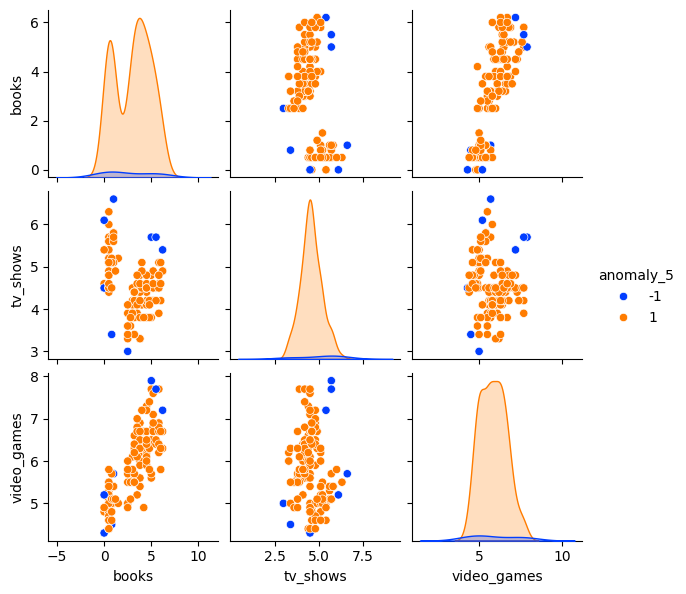

In [12]:
# overlay the isolation forest detected outliers
sns.pairplot(df.drop(columns=['anomaly_scores', 'anomaly', 'anomaly_scores_5']), hue='anomaly_5', palette='bright', height=2);

In [13]:
# dbscan function (copied from clustering section) to find a good eps + min_samples combo
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
 
def tune_dbscan(data):
 
    results = []
 
    # define a range of eps and min_samples values to loop through
    eps_values = np.arange(.1, 2, .1)
    min_samples_values = np.arange(2, 10, 1)
 
    # loop through the combinations of eps and min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            dbscan.fit(data)
            labels = dbscan.labels_
 
            # count the number of clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
 
            # count the number of noise points (labeled as -1)
            n_noise = list(labels).count(-1)
 
            # calculate the silhouette score (excluding noise points)
            if n_clusters > 1:  # silhouette score requires at least 2 clusters
                silhouette = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                silhouette = None
 
            results.append([eps, min_samples, n_clusters, n_noise, silhouette])
 
    # put the results in a dataframe
    dbscan_results = pd.DataFrame(results, columns=["Eps", "Min Samples", "Number of Clusters",
                                                    "Number of Noise Points", "Silhouette Score"])
    return dbscan_results

In [14]:
# view the results on the original data
dbscan_results = tune_dbscan(X)
dbscan_results.head(10)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
0,0.1,2,12,124,-0.438782
1,0.1,3,2,144,-0.483479
2,0.1,4,0,150,NaN
3,0.1,5,0,150,NaN
4,0.1,6,0,150,NaN
5,0.1,7,0,150,NaN
6,0.1,8,0,150,NaN
7,0.1,9,0,150,NaN
8,0.2,2,25,87,-0.184281
9,0.2,3,7,123,-0.418327


In [15]:
# top silhouette scores
dbscan_results.sort_values(by='Silhouette Score', ascending=False).head(10)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
110,1.4,8,2,0,0.628673
111,1.4,9,2,0,0.628673
112,1.5,2,2,0,0.628673
113,1.5,3,2,0,0.628673
114,1.5,4,2,0,0.628673
115,1.5,5,2,0,0.628673
116,1.5,6,2,0,0.628673
117,1.5,7,2,0,0.628673
118,1.5,8,2,0,0.628673


In [16]:
# return one eps + min_samples combo for each silhouette score
(dbscan_results.sort_values('Silhouette Score', ascending=False)
               .groupby('Silhouette Score')
               .head(1)).head(10)

,Eps,Min Samples,Number of Clusters,Number of Noise Points,Silhouette Score
109,1.4,7,2,0,0.628673
77,1.0,7,2,2,0.550831
66,0.9,4,2,3,0.528540
72,1.0,2,2,1,0.515323
57,0.8,3,2,4,0.497686
59,0.8,5,2,5,0.482653
43,0.6,5,2,12,0.480329
52,0.7,6,2,9,0.476795
42,0.6,4,2,11,0.476287
63,0.8,9,2,6,0.471959


In [17]:
# fit a dbscan model
dbscan = DBSCAN(eps=1, min_samples=6)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",6
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [18]:
# view the anomaly labels from dbscan
df['anomaly_dbscan'] = dbscan.labels_
df.head()

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5,anomaly_5,anomaly_dbscan
0,Aaliyah,0.5,4.6,4.9,0.189862,1,0.162808,1,0
1,Abigail,0.0,4.5,4.8,0.117725,1,0.077601,1,0
2,Addison,0.5,4.5,5.0,0.187014,1,0.150499,1,0
3,Adeline,3.5,4.5,6.6,0.191806,1,0.176864,1,1
4,Alana,2.8,3.8,5.6,0.165829,1,0.150290,1,1


In [19]:
# view specific anomalies
df[df['anomaly_dbscan'] == -1]

,name,books,tv_shows,video_games,anomaly_scores,anomaly,anomaly_scores_5,anomaly_5,anomaly_dbscan
37,Elena,0.8,3.4,4.5,0.000398,1,-0.034636,-1,-1
110,Octavia,5.0,5.7,7.9,-0.041649,-1,-0.040416,-1,-1


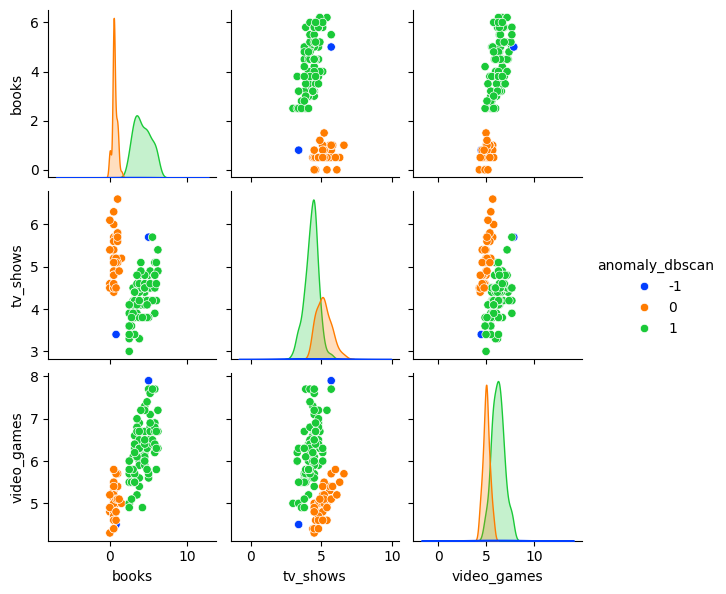

In [20]:
# create a pair plot
sns.pairplot(df[['books', 'tv_shows', 'video_games', 'anomaly_dbscan']], hue='anomaly_dbscan', palette='bright', height=2);

In [21]:
# read in entertainment data
import pandas as pd
 
df = pd.read_csv('entertainment_clean.csv')
df.head()

,name,books,tv_shows,video_games
0,Aaliyah,0.5,4.6,4.9
1,Abigail,0.0,4.5,4.8
2,Addison,0.5,4.5,5.0
3,Adeline,3.5,4.5,6.6
4,Alana,2.8,3.8,5.6


In [22]:
# remove the id column
data = df.iloc[:, 1:]
data.head()

,books,tv_shows,video_games
0,0.5,4.6,4.9
1,0.0,4.5,4.8
2,0.5,4.5,5.0
3,3.5,4.5,6.6
4,2.8,3.8,5.6


In [23]:
# view the mean of each column of the data
data.mean()

books          2.993333
tv_shows       4.586000
video_games    5.843333
dtype: float64

In [24]:
# center the data
df_centered = data - data.mean()
df_centered.head()

,books,tv_shows,video_games
0,-2.493333,0.014,-0.943333
1,-2.993333,-0.086,-1.043333
2,-2.493333,-0.086,-0.843333
3,0.506667,-0.086,0.756667
4,-0.193333,-0.786,-0.243333


In [25]:
# import pca from sklearn
from sklearn.decomposition import PCA

In [26]:
# fit a pca model on the centered data
pca = PCA(n_components=2)
pca.fit(df_centered)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [27]:
# fit a pca model on the centered data
pca3 = PCA(n_components=3)
pca3.fit(df_centered)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [28]:
# view the explained variance ratio on full data set
pca3.explained_variance_ratio_

array([0.88175186, 0.08603611, 0.03221203])

In [29]:
# it adds up to 1
round(sum(pca3.explained_variance_ratio_))

1

In [30]:
# view the new components, or new x and y axes
pca.components_

array([[ 0.93143032, -0.11629655,  0.34483717],
       [-0.04900906,  0.89884697,  0.43551376]])

In [31]:
# view the columns again
df_centered.columns

Index(['books', 'tv_shows', 'video_games'], dtype='str')

In [32]:
pca.transform(df_centered)

array([[-2.64929081, -0.27605485],
       [-3.13786003, -0.38498639],
       [-2.60317744, -0.32238817],
       [ 0.74285299,  0.22740664],
       [-0.17257782, -0.80299365],
       [ 2.97696422,  0.33522462],
       [ 1.42933793,  0.23665167],
       [ 0.11858673, -0.19340439],
       [-3.11500597, -0.25155032],
       [ 1.04818447, -0.41794493],
       [ 1.79017461, -0.40724393],
       [-2.74151755, -0.18338821],
       [-2.20724021,  0.19241548],
       [-2.6380664 , -0.05273408],
       [-2.70784433,  0.4865741 ],
       [-2.14029901,  1.84554557],
       [ 0.5704344 ,  0.00964977],
       [-2.63847165,  0.26047139],
       [ 3.24567995,  0.49817233],
       [ 3.33424154,  0.05444274],
       [ 0.91842569,  0.39525526],
       [ 0.95493564, -1.1272207 ],
       [ 0.32589427, -0.24530161],
       [ 2.07062579,  0.37999576],
       [ 0.16510535, -0.55294318],
       [ 1.58246181, -0.04214125],
       [-2.79845008, -0.67358112],
       [-2.42882048,  0.78507685],
       [-2.62765249,

In [33]:
# view the transformed data
df_transformed = pd.DataFrame(pca.transform(df_centered),
                                columns=['pc1', 'pc2'])
df_transformed.head(10)

,pc1,pc2
0,-2.649291,-0.276055
1,-3.137860,-0.384986
2,-2.603177,-0.322388
3,0.742853,0.227407
4,-0.172578,-0.802994
5,2.976964,0.335225
6,1.429338,0.236652
7,0.118587,-0.193404
8,-3.115006,-0.251550
9,1.048184,-0.417945


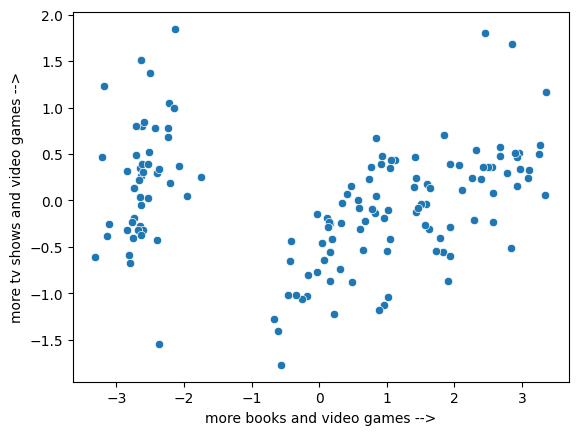

In [34]:
# view the data on a scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.scatterplot(x='pc1', y='pc2', data=df_transformed)
plt.xlabel('more books and video games -->')
plt.ylabel('more tv shows and video games -->');

In [37]:
# read in the cereal data
cereal_data = pd.read_csv('cereal.csv')
cereal_data

,Cereal Name,Manufacturer,Calories,Protein (g),Fat,Sugars,Vitamins and Minerals
0,100%_Bran,Nabisco,70,4,1,6,25
1,100%_Natural_Bran,Quaker Oats,120,3,5,8,0
2,All-Bran,Kelloggs,70,4,1,5,25
3,All-Bran_with_Extra_Fiber,Kelloggs,50,4,0,0,25
4,Almond_Delight,Ralston Purina,110,2,2,8,25
...,...,...,...,...,...,...,...
69,Triples,General Mills,110,2,1,3,25
70,Trix,General Mills,110,1,1,12,25
71,Wheat_Chex,Ralston Purina,100,3,1,3,25
72,Wheaties,General Mills,100,3,1,3,25


In [38]:
# view the nutritional facts of a subset of the data
cereal = cereal_data[['Calories', 'Protein (g)', 'Sugars', 'Vitamins and Minerals']]
cereal.head()

,Calories,Protein (g),Sugars,Vitamins and Minerals
0,70,4,6,25
1,120,3,8,0
2,70,4,5,25
3,50,4,0,25
4,110,2,8,25


In [39]:
# center the data
from sklearn.preprocessing import StandardScaler
 
cereal_scaler = StandardScaler()
cereal_std = cereal_scaler.fit_transform(cereal)
cereal_centered = pd.DataFrame(cereal_std)
cereal_centered.head()

,0,1,2,3
0,-1.940286,1.387392,-0.173586,-0.149270
1,0.789394,0.462464,0.277129,-1.253871
2,-1.940286,1.387392,-0.398944,-0.149270
3,-3.032158,1.387392,-1.525731,-0.149270
4,0.243458,-0.462464,0.277129,-0.149270


In [40]:
# fit a pca model
pca_cereal = PCA(n_components=2)
pca_cereal.fit(cereal_centered)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [41]:
# view the components
pca_cereal.components_

array([[ 0.59747165, -0.35719665,  0.6401387 ,  0.3250548 ],
       [ 0.2800528 ,  0.68024865, -0.20898945,  0.6443257 ]])

In [42]:
# transform the original data into the pc1/pc2 space
cereal_2d = pd.DataFrame(pca_cereal.transform(cereal_centered), columns=['PC1', 'PC2'])
cereal_2d.head(10)

,PC1,PC2
0,-1.814478,0.340488
1,0.076274,-0.330156
2,-1.958738,0.387585
3,-3.332400,0.317290
4,0.439530,-0.400505
5,0.728050,-0.494700
6,1.305090,-0.683089
7,0.761511,0.534458
8,-0.501353,-0.612092
9,-0.975994,0.064186


In [43]:
import plotly.graph_objects as go
 
# Create a Plotly scatter plot with labels
fig = go.Figure()
 
# Scatter plot trace
scatter_trace = go.Scatter(
    x=cereal_2d['PC1'],
    y=cereal_2d['PC2'],
    mode='markers',
    marker=dict(color='blue', size=10),
    text=cereal_data['Cereal Name'],  # Labels for hover
)
 
# Add trace to the figure
fig.add_trace(scatter_trace)
 
# Add data labels using annotations
for i, label in enumerate(cereal_data['Cereal Name']):
    fig.add_annotation(
        x=cereal_2d['PC1'].iloc[i],
        y=cereal_2d['PC2'].iloc[i],
        text=label,
        showarrow=False,
        xanchor='left',
        xshift=5,
        font=dict(color='black', size=10),
    )
 
# Update layout with axis labels
fig.update_layout(
    title='Comparing Cereals by Nutritional Facts',
    xaxis=dict(title='<-- Higher Sugar & Calorie Cereals          Higher Protein Cereals -->'),
    yaxis=dict(title='Higher Protein, Vitmains and Minerals Cereals -->'),
    height=650,
    width=800,
)
 
# Show the interactive plot
fig.show()
 

In [44]:
# import tsne from sklearn
from sklearn.manifold import TSNE
 

In [45]:
# create a tsne object
tsne = TSNE(n_components=2, random_state=42)

In [47]:
tsne.fit_transform(data)

array([[-2.55906734e+01,  3.14864922e+00],
       [-2.64624844e+01,  2.50207496e+00],
       [-2.56666279e+01,  2.85571408e+00],
       [ 8.70913696e+00, -4.79919577e+00],
       [ 3.72856259e+00, -5.98974991e+00],
       [ 1.45684729e+01,  1.55508608e-01],
       [ 1.05104675e+01, -2.91696763e+00],
       [ 5.60340595e+00, -5.10255337e+00],
       [-2.60889721e+01,  2.31641483e+00],
       [ 7.39438534e+00, -2.75927138e+00],
       [ 1.14031954e+01, -1.04322731e+00],
       [-2.53935337e+01,  3.85694242e+00],
       [-2.35384064e+01,  5.16258812e+00],
       [-2.48800735e+01,  3.20754862e+00],
       [-2.28027992e+01,  3.19103336e+00],
       [-2.00246048e+01,  4.17393589e+00],
       [ 7.22869301e+00, -4.58514404e+00],
       [-2.36697350e+01,  3.63804245e+00],
       [ 1.51472120e+01,  9.89596725e-01],
       [ 1.49503412e+01, -1.51334977e+00],
       [ 9.11796856e+00, -3.62068415e+00],
       [ 4.75769711e+00, -2.61150002e+00],
       [ 6.38363123e+00, -5.43863058e+00],
       [ 1.

In [48]:
# fit a model and transform the data into a lower dimensionality space
data_tsne = tsne.fit_transform(data)

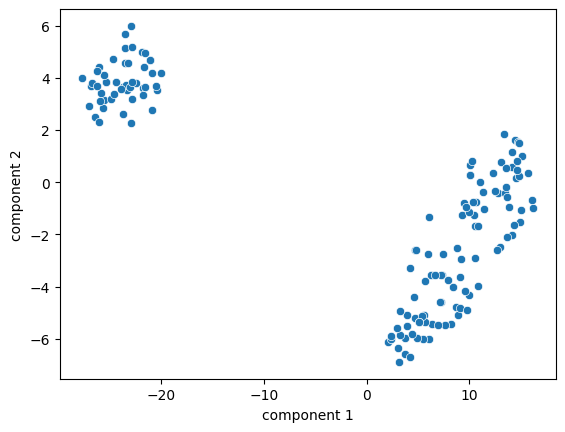

In [49]:
# plot the data
df_tsne = pd.DataFrame(data_tsne,
                       columns=['component 1','component 2'])
 
sns.scatterplot(x='component 1',
                y='component 2',
                data=df_tsne);

In [50]:
# create a tsne object
tsne_cereal = TSNE(n_components=2, random_state=42)

In [51]:
# fit a model and transform the data into a lower dimensionality space
data_tsne_cereal = tsne.fit_transform(cereal)

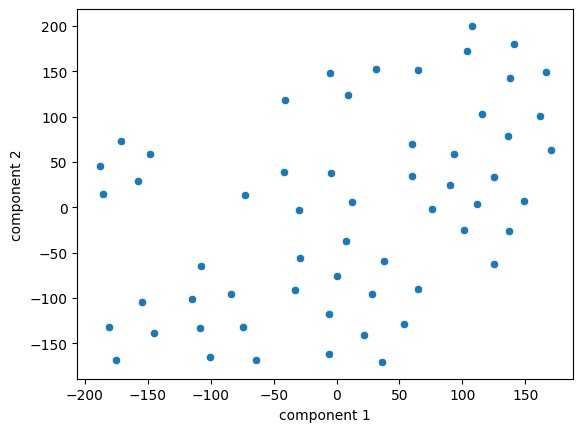

In [52]:
# plot the data
df_tsne_cereal = pd.DataFrame(data_tsne_cereal,
                       columns=['component 1','component 2'])
 
sns.scatterplot(x='component 1',
                y='component 2',
                data=df_tsne_cereal);

In [53]:
import plotly.graph_objects as go
 
# Create a Plotly scatter plot with labels
fig = go.Figure()
 
# Scatter plot trace
scatter_trace = go.Scatter(
    x=df_tsne_cereal['component 1'],
    y=df_tsne_cereal['component 2'],
    mode='markers',
    marker=dict(color='blue', size=10),
    text=cereal_data['Cereal Name'],  # Labels for hover
)
 
# Add trace to the figure
fig.add_trace(scatter_trace)
 
# Add data labels using annotations
for i, label in enumerate(cereal_data['Cereal Name']):
    fig.add_annotation(
        x=df_tsne_cereal['component 1'].iloc[i],
        y=df_tsne_cereal['component 2'].iloc[i],
        text=label,
        showarrow=False,
        xanchor='left',
        xshift=5,
        font=dict(color='black', size=10),
    )
 
# Update layout with axis labels
fig.update_layout(
    title='Comparing Cereals by Nutritional Facts',
    xaxis=dict(title='Component 1'),
    yaxis=dict(title='Component 2'),
    height=650,
    width=1000,
)
 
# Show the interactive plot
fig.show()
 

In [54]:
# Import KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, n_init='auto', random_state=42)
 
# Fit the model to the data
kmeans.fit(df_centered)
 
# Get the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

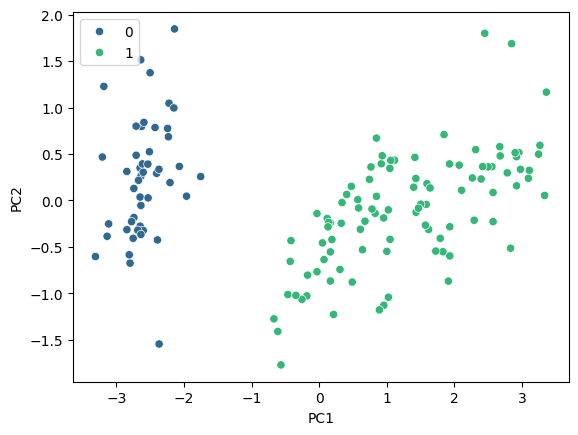

In [55]:
# Plot the PCA results with colors
sns.scatterplot(x='PC1',
                y='PC2',
                data=pd.DataFrame(pca.transform(df_centered), columns=['PC1','PC2']), hue=labels, palette='viridis');

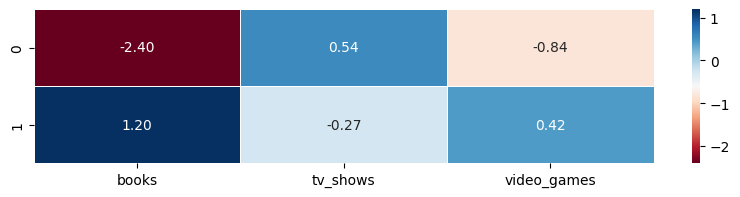

In [56]:
# Interpret the cluster centers
 
# Create a DataFrame for the heatmap
centroids_df = pd.DataFrame(centroids, columns=data.columns)
 
# Create the heatmap
plt.figure(figsize=(10, 2))
sns.heatmap(centroids_df, annot=True, cmap="RdBu", fmt=".2f", linewidths=.5)
 
# Show the plot
plt.show()

In [57]:
# Try the same with the cereal data
kmeans_cereal = KMeans(n_clusters=5, n_init='auto', random_state=42)
 
# Fit the model to the data
kmeans_cereal.fit(cereal_centered)
 
# Get the cluster labels
labels_cereal = kmeans_cereal.labels_
 

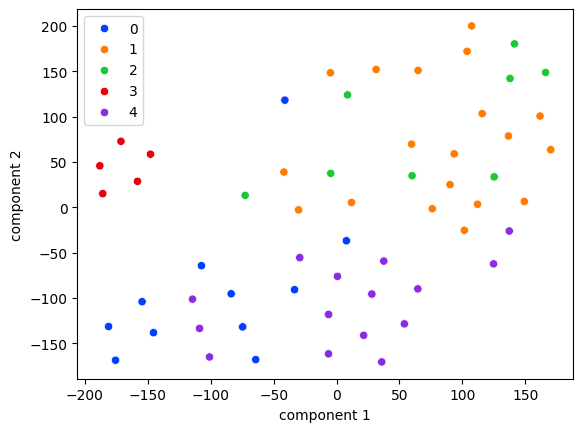

In [58]:
# Plot the t-SNE results with colors
sns.scatterplot(x='component 1',
                y='component 2',
                data=df_tsne_cereal, hue=labels_cereal, palette='bright');